# Tutorial about fluopy - three state simulation

Here we outline a simulation procedure for an ideal three state system.

In [1]:
from pprint import pprint

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import fluopy
import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

In [2]:
fluopy.__version__

'0.1.0.dev218+g6a7acd3b1.d20250915'

In [3]:
rng = np.random.default_rng(seed=1)

## Set up the photophysical system

Set up a single fluorophore representing a three state system (tss).

### Define the transitions

In [4]:
transitions = {
    "tss": [
        tr.Transition(tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0]),
        tr.Transition(
            tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0]
        ),
        tr.Transition(
            tr.TransitionType.INTERSYSTEM_CROSSING_ST, rate=1e6, fluorophore_ids=[0]
        ),
        tr.Transition(
            tr.TransitionType.S1_S0_TRANSITIONS, rate=1e9, fluorophore_ids=[0]
        ),
        tr.Transition(
            tr.TransitionType.T1_S0_TRANSITIONS, rate=1e6, fluorophore_ids=[0]
        ),
    ]
}
pprint(transitions)

{'tss': [Transition(identity=None,
                    transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>,
                    abbreviation='EXC',
                    initial_state=<SingleState.S0: 0>,
                    final_state=<SingleState.S1: 1>,
                    rate=1000000000.0,
                    photon=False,
                    fluorophore_ids=[0]),
         Transition(identity=None,
                    transition_type=<TransitionType.FLUORESCENT_EMISSION: TransitionAttributes(abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=True)>,
                    abbreviation='FLU',
                    initial_state=<SingleState.S1: 1>,
                    final_state=<SingleState.S0: 0>,
                    rate=1000000000.0,
                    photon=True,
                    fluorophore_ids=[0]),
         Transitio

### Define the fluorophore system

In [5]:
fluorophore = fl.Fluorophore(name="tss", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])

There is no FluorophoreData for Fluorophore tss in fluopy.fluo_data. Parameters have to be defined manually.


In [6]:
pprint(vars(fluorophore_system))

{'count': 1,
 'distances': {},
 'fluorophores': [Fluorophore(identity=0,
                              name='tss',
                              position=array([0, 0]),
                              constants=None)],
 'multi_type': False}


### Alternatively: define the fluorophore system with FluorophoreData

In [7]:
fluorophore_data_tss = fluopy.fluo_data.FluorophoreData(
    QUANTUM_YIELD=1,
    FLUORESCENCE_LIFETIME=2e-9,
    S1_QUENCH_RATE=1e9,
    ISC_ST_RATE=1e6,
    ISC_TS_RATE=1e6,
    PHOTOBLEACH_T1_RATE=10,
)
pprint(fluorophore_data_tss)

FluorophoreData(data_files=None,
                QUANTUM_YIELD=1,
                FLUORESCENCE_LIFETIME=2e-09,
                S1_QUENCH_RATE=1000000000.0,
                ISC_ST_RATE=1000000.0,
                ISC_TS_RATE=1000000.0,
                RISC_RATE=0,
                STA_EFFICIENCY=0,
                PHOTOBLEACH_T1_RATE=10,
                PHOTOBLEACH_T2_RATE=0,
                DSTORM_PET_T_RATE_MOL=0,
                DSTORM_PET_S_RATE_MOL=0,
                DSTORM_PET_SUCCESS_RATE=0,
                DSTORM_TH_EL_RATE_1=0,
                DSTORM_TH_EL_RATE_2=0,
                DSTORM_P_EL_CROSS_SECTION=0,
                RAD_ESCAPE_EFFICIENCY=0,
                RAD_RELAX_RATE=0,
                OFRET_EFFICIENCY=0,
                ISO_RATE=0,
                BISO_CROSS_SECTION=0,
                BISO_THERMAL_RATE=0,
                BISO_EFFICIENCY=0,
                H2O_ATTACK_S=0,
                H2O_ATTACK_T=0,
                BACK_REACTION=0)


In [8]:
fluorophore_tss = fl.Fluorophore(
    name="tss", position=[0, 0], constants=fluorophore_data_tss
)
fluorophore_system_tss = fl.FluorophoreSystem(fluorophores=[fluorophore_tss])

In [9]:
pprint(vars(fluorophore_system_tss))

{'count': 1,
 'distances': {},
 'fluorophores': [Fluorophore(identity=0,
                              name='tss',
                              position=array([0, 0]),
                              constants=FluorophoreData(data_files=None,
                                                        QUANTUM_YIELD=1,
                                                        FLUORESCENCE_LIFETIME=2e-09,
                                                        S1_QUENCH_RATE=1000000000.0,
                                                        ISC_ST_RATE=1000000.0,
                                                        ISC_TS_RATE=1000000.0,
                                                        RISC_RATE=0,
                                                        STA_EFFICIENCY=0,
                                                        PHOTOBLEACH_T1_RATE=10,
                                                        PHOTOBLEACH_T2_RATE=0,
                                                       

THIS IS NOT YET WORKING.

### Define the transition set

In [10]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

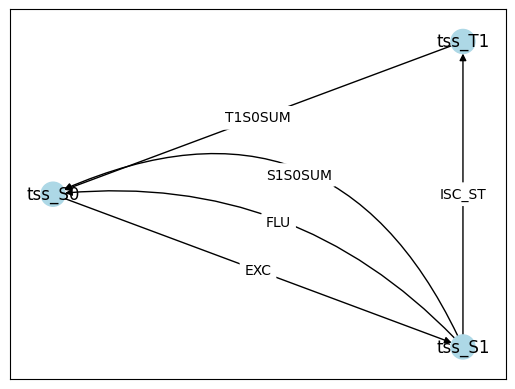

In [11]:
transition_set.plot(graph_type="shell", colors=None, scale=1);

In [12]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
tss         0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST       ISC_ST   
            3               TransitionType.S1_S0_TRANSITIONS      S1S0SUM   
            4               TransitionType.T1_S0_TRANSITIONS      T1S0SUM   

                       initial_state     final_state          rate  photon  \
Fluorophore identity                                                         
tss         0         SingleState.S0  SingleState.S1  1.000000e+09   False   
            1         SingleState.S1  SingleState.S0  1.000000e+09    True   
            2         SingleState.S1  SingleState.T1  1.000000e+06   False   
            3         SingleState.S1  SingleState.S0  1.000000e+09   False   
            4         SingleState.T1  SingleState.S0  1.000000e+06   False   

                     fluorophore_ids  absorbing  
Fluorophore identity                             
tss         0                    [0]      False  
            1                    [0]      False  
            2                    [0]      False  
            3                    [0]      False  
            4                    [0]      False

## Make a prediction

In [13]:
%%time
prediction = pr.Prediction(transition_set)
prediction

CPU times: total: 0 ns
Wall time: 5.43 ms


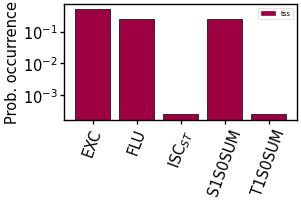

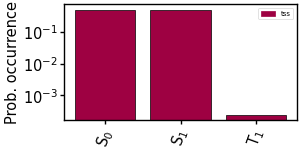

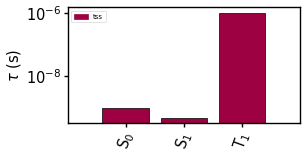

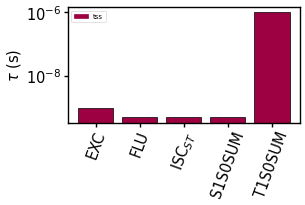

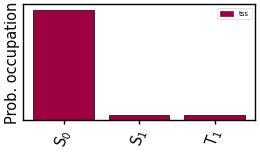

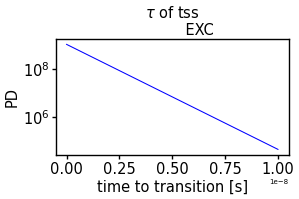

In [14]:
prediction.plot_frequency_transitions(scale=0.5)
prediction.plot_frequency_states(scale=0.5)
prediction.plot_mean_lifetimes(scale=0.5)
prediction.plot_mean_transition_times(scale=0.5)
prediction.plot_state_occupations(scale=0.5)
prediction.plot_transition_time_distributions(
    fluorophore="tss", transition_id=0, scale=0.5
);

## Run a simulation

In [15]:
simulation = si.Simulation(transition_set)
simulation

In [16]:
%%time
# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=1e-2, seed=rng, use_memmap=None)
mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 1.73e-18.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1]
 gives a probability of 3.47e-09 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x00000274F4D31940>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x00000274F4D31160>
_________________________________________________________________
time_series = array([0.00000000e+00, 6.69779104e-10, 1.6377122...99999900e-03, 1.00000000e-02], shape=(10120486,))
_________________________________________________________________
transition_series = array([0, 3, 0, ..., 1, 0, 1], shape=(10120484,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 1, 0, ..., 0, 1, 0]], shape=(1, 10120485), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________


CPU times: total: 39.1 s
Wall time: 39.4 s


## Analyze the simulation

In [17]:
analysis = an.Analysis(simulation=simulation)
mi.print_class(analysis)

Attributes of <fluopy.analysis.Analysis object at 0x00000274F4D33380>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x00000274F4D31940>
_________________________________________________________________
frequency_transitions = array([4.99877674e-01, 2.49882812e-01, 2.44652331e-04, 2.49750210e-01,
       2.44652331e-04])
_________________________________________________________________
frequency_states = {'tss': array([4.99877723e-01, 4.99877624e-01, 2.44652307e-04])}
_________________________________________________________________
transition_time_distributions = [array([6.69779104e-10, 1.16529246e-09, 5.9857602....80394562e-10, 1.09146311e-09], shape=(5059004,)), array([9.45034359e-11, 5.96391644e-10, 7.9575674....05701042e-09, 3.83651617e-10], shape=(2528935,)), array([2.39036925e-11, 3.90133768e-10, 1.1099050..., 1.57139638e-10, 2.02107909e-09], shape=(2476,)), array([9.67933119e-10, 1.41433715e-10, 3.6142563..

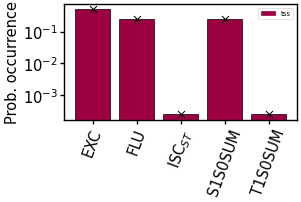

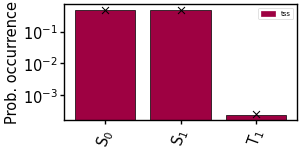

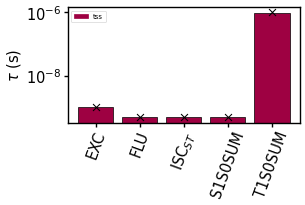

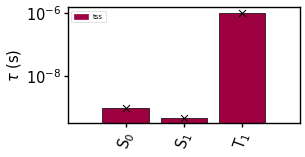

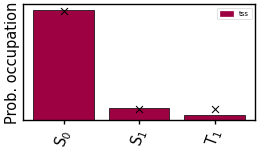

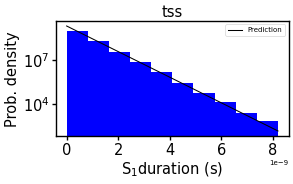

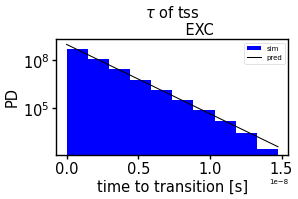

In [18]:
analysis.get_fluorescence_lifetimes(fluorophore="tss")
analysis.get_emitting_transition_lifetimes(fluorophore="tss")

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
analysis.plot_state_occupations(scale=0.5, prediction=prediction)
analysis.plot_lifetime_distributions(
    scale=0.5, prediction=prediction, fluorophore="tss", state_identity=1
)
analysis.plot_transition_time_distributions(
    scale=0.5, prediction=prediction, fluorophore="tss", transition_id=0
);

## Simulation of experimentally observable (photons per frames) only

#### Extract photon emission events from simulation

In [19]:
%%time
emissions = em.Emissions(frame_time="1us", seed=rng)
emissions.extract(simulation=simulation)
emissions

CPU times: total: 1.06 s
Wall time: 1.06 s


#### Simulate photon emission events

Correct for detection efficiency and noise contributions:

In [20]:
emissions.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)
emissions

emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(660, 700))
emissions.extract(simulation=approximation)  

In [21]:
# 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
p_photon_collection = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emissions.add_photon_collection_objective(p=p_photon_collection)  # 1.
emissions.add_quantum_efficiency(p=0.9)  # 4.1.
emissions.add_transmittance(p=0.99)  # 3 (depending on number of components of optical
# path, may be applied multiple times)
emissions.add_poisson_noise(rate=0.05)  # 4.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10)  # 5. (+ multiplicative noise)
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 6. (readout noise)
# CIC (spurious noise) neglected since low probability to happen in the pixels of
# interest
emissions.apply_threshold(threshold=100)  # 7 (thresholding)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

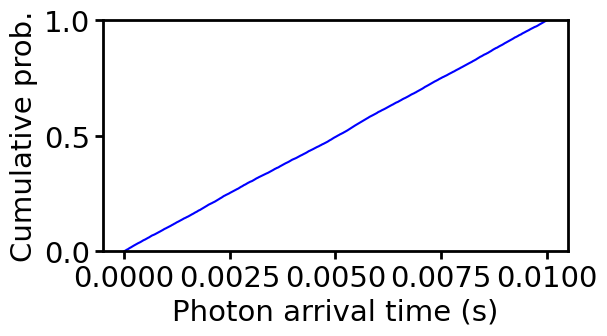

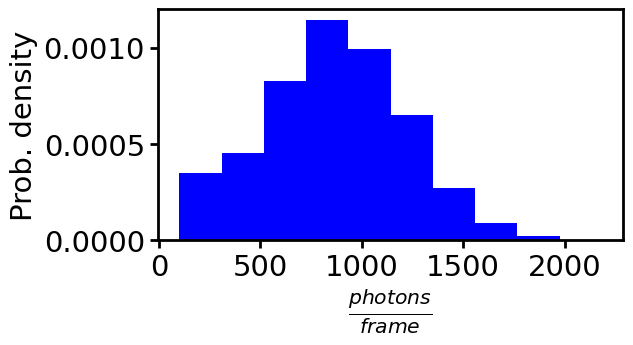

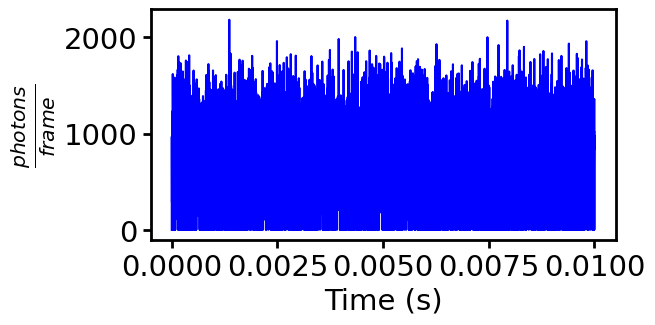

In [22]:
emissions.plot_cumulative_events(scale=1)
emissions.plot_histogram(scale=1)
emissions.plot_time_series(scale=1)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

## Simulation of pulsed excitation

In [23]:
%%time
emissions_tcspc = em.Emissions(frame_time="10us", seed=rng, bandpass=None)
lifetimes_DA, lifetimes_D, lifetimes_all = emissions_tcspc.tcspc(
    transition_set=transition_set,
    number_pulses=1e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"tss": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)

the last frame (of index 0.01) has 1.00e+00 times the pulses of other frames.


CPU times: total: 15.5 s
Wall time: 15.6 s


array([[<Axes: xlabel='Lifetime (s)', ylabel='PD'>]], dtype=object)

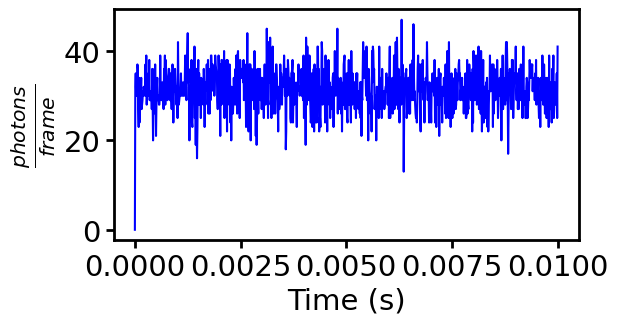

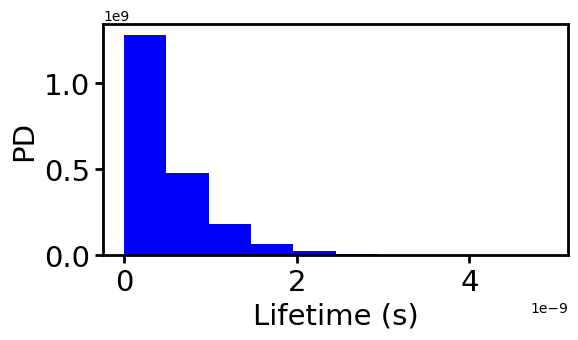

In [24]:
emissions_tcspc.plot_time_series()
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
)

## Fluorescence correlation spectroscopy

Observed fluorescence emission events can be analyzed by a correlation analysis.

In [25]:
fcs = fcs_p.FCS(emissions)
list(vars(fcs).keys())

['emissions', 'autocorrelation', 'tau']

### Autocorrelation of time points

In [26]:
%%time
fcs.autocorrelate_time_points(
    exp_min=-20, exp_max=-2, points_per_base=4, base=4, normalize=True
)

The exp_max -2 yields a base to the power of exp_max 0.0625 that is larger than the last time point 0.009999998997343471. Therefore, exp_max is adjusted to -4.


CPU times: total: 5.69 s
Wall time: 5.97 s


Attributes of <fluopy.fcs.FCS object at 0x00000274F4D32900>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000274F4D33620>
_________________________________________________________________
autocorrelation = array([0.        , 0.00586969, 0.008301  , 0.014... 1.02426268, 1.03786409, 1.05680552, 1.0876308 ])
_________________________________________________________________
tau = array([1.09785722e-12, 1.55260457e-12, 2.1957144... 1.66709647e-03, 2.35763043e-03, 3.33419293e-03])
_________________________________________________________________




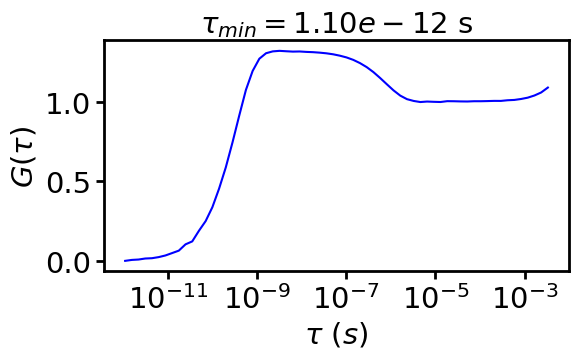

In [27]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

### Autocorrelation of time series

In [28]:
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

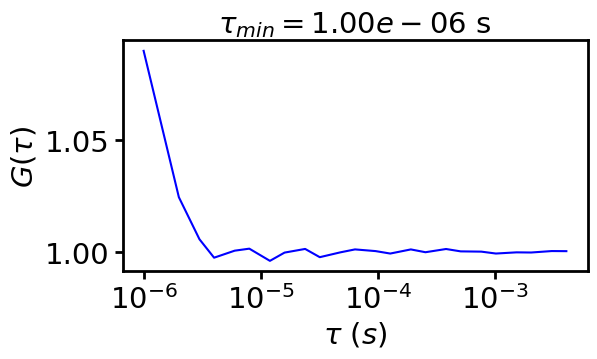

In [29]:
fcs.plot(normalize_to=None, unit="s", scale=1);

## Antibunching

Alternatively, you can focus on fast time scales in a linear scale and observe antibunching.

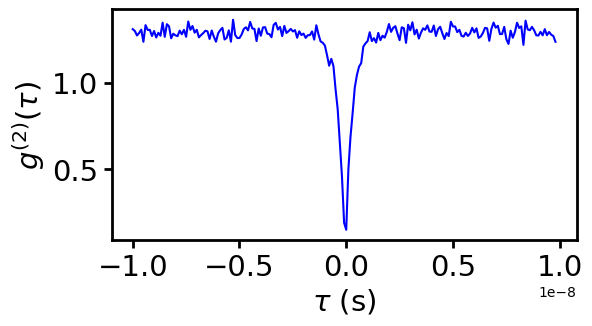

In [30]:
# sensible to tau_max and bin_width, see coincidence notebook
hist, bins = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-8, bin_width=1e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bins[:-2], hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=1,
);

## Blinking

### Emissions from a short simulation

In [31]:
%%time
emissions = em.Emissions(frame_time="200ns", seed=rng, bandpass=None)
emissions.simulate(transition_set=transition_set, store_time_points=False, frames=2000)
emissions

CPU times: total: 3.44 s
Wall time: 3.44 s


In [32]:
threshold: int = 40

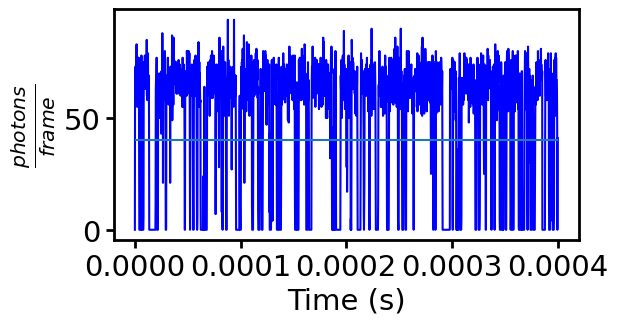

In [33]:
emissions.plot_time_series(scale=1)
plt.hlines(threshold, xmin=0, xmax=0.0004)

In [34]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [35]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x0000027484D85010>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000002748A68FB10>
_________________________________________________________________
on_periods = array([19,  2, 26,  5, 23, 12, 18, 68, 22, 12, 1... 23,  4,  2, 13,  9,  2,  6, 34, 18,  1,  9, 15])
_________________________________________________________________
off_periods = array([11,  9, 31,  6,  1,  3,  1,  2,  3,  4,  ...  4,  7, 11,  2,  1,  8,  9, 13,  7,  1,  7,  1])
_________________________________________________________________
on_periods_frames = array([   1,   31,   42,   99,  110,  134,  149,...1869,
       1879, 1894, 1941, 1966, 1968, 1984])
_________________________________________________________________
off_periods_frames = array([  20,   33,   68,  104,  133,  146,  167,...1871,
       1885, 1928, 1959, 1967, 1977, 1999])
_________________________________________________________

array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

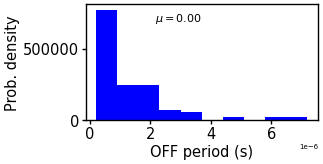

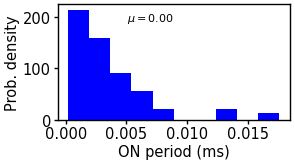

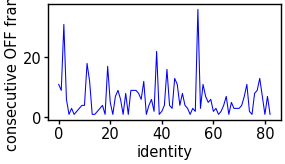

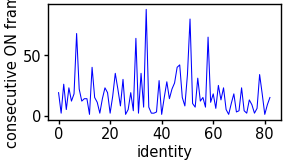

In [36]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

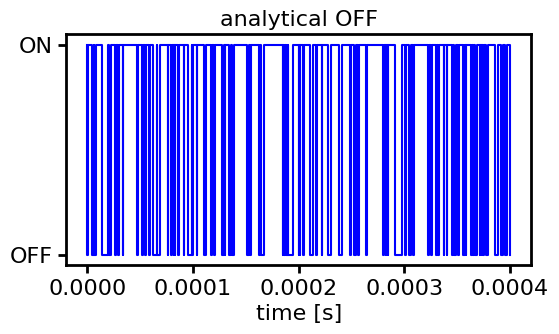

In [37]:
# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=1, title="analytical OFF"
);

### Emissions from the long simulation

Get more detailed information from a complete simulation:

In [38]:
%%time
emissions = em.Emissions(frame_time="200ns", seed=rng, bandpass=None)
emissions.extract(simulation=simulation)
emissions

CPU times: total: 1.05 s
Wall time: 1.06 s


In [39]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [40]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x000002748A928CD0>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x0000027484D196E0>
_________________________________________________________________
on_periods = array([ 8,  8, 12, ..., 22, 12, 58], shape=(2152,))
_________________________________________________________________
off_periods = array([ 6,  5,  9, ..., 11,  5, 17], shape=(2152,))
_________________________________________________________________
on_periods_frames = array([    1,    15,    28, ..., 49864, 49897, 49914], shape=(2152,))
_________________________________________________________________
off_periods_frames = array([    9,    23,    40, ..., 49886, 49909, 49972], shape=(2152,))
_________________________________________________________________




array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

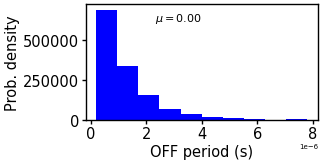

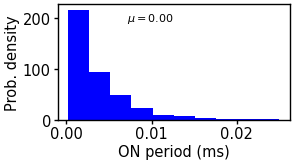

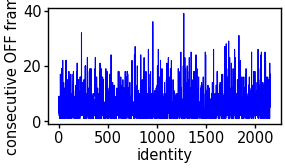

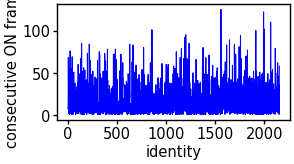

In [41]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

Get more detailed information from a complete simulation:

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

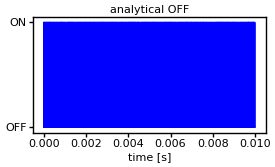

In [42]:
# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=1, title="analytical OFF"
);